In [23]:
!pip install pymc

In [24]:
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

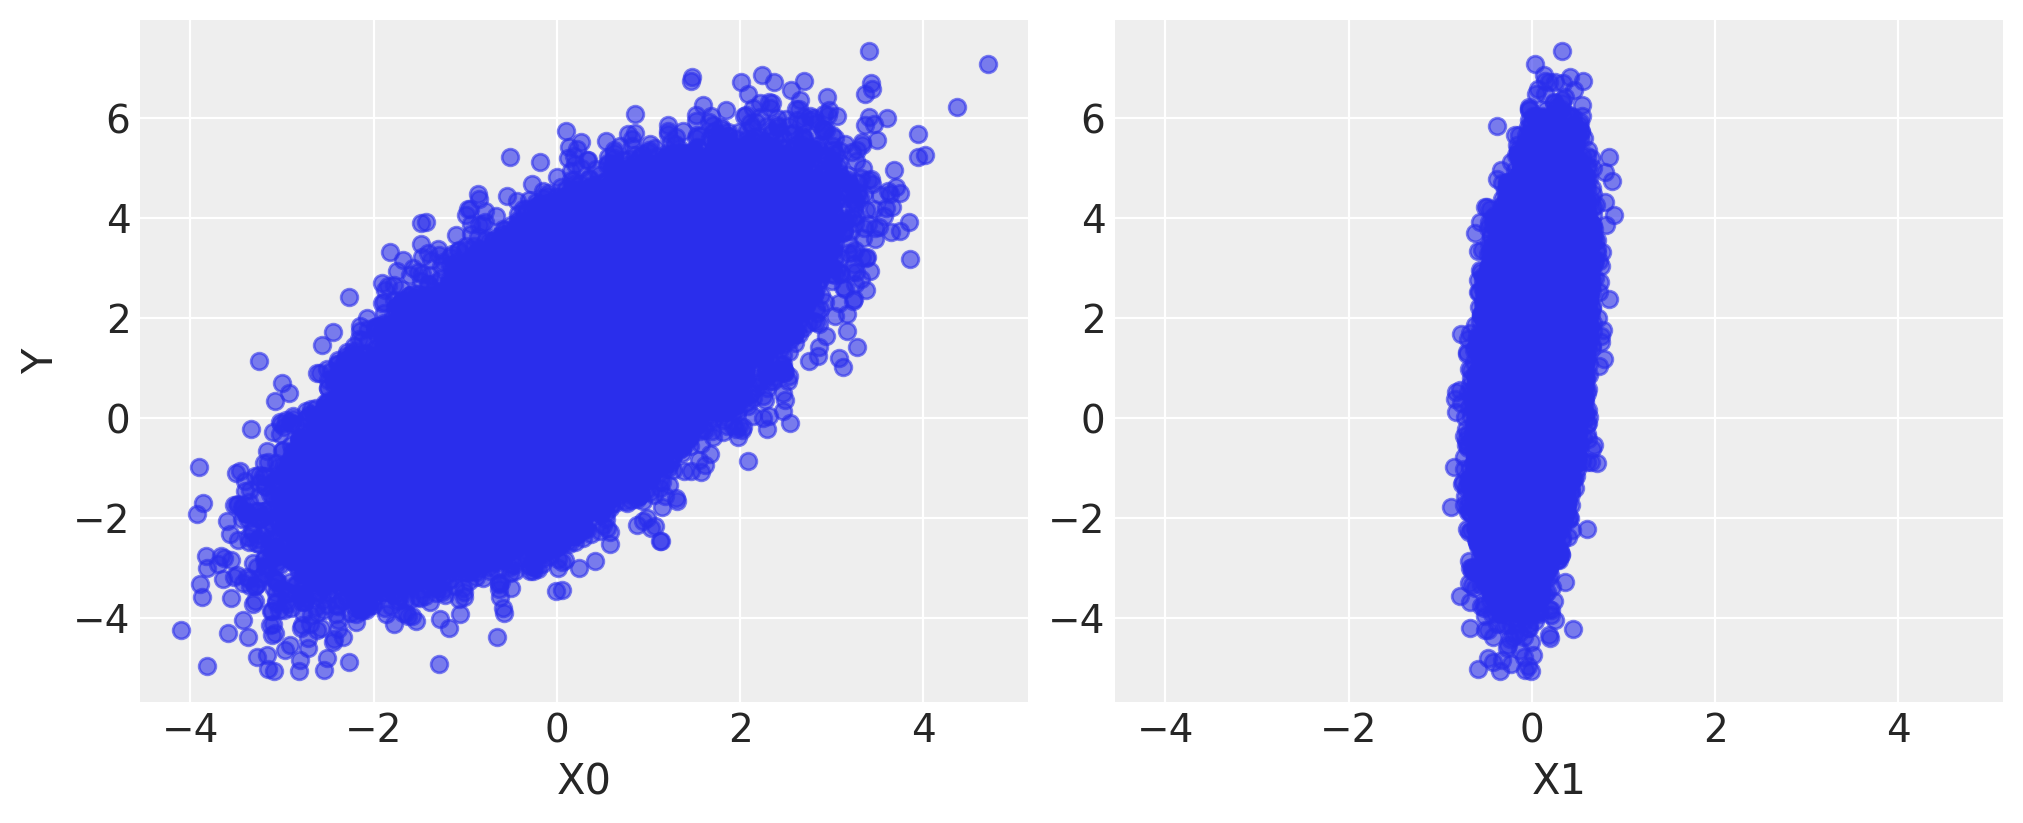

In [25]:
# 推定したい真のパラメータ
alpha, sigma = 1, 1
beta = [1, 2.5]

# データセットの大きさ
size = 100000

# 確率変数 X0, X1
X0 = np.random.randn(size)
X1 = np.random.randn(size) * 0.2

# 観測された値
Y = alpha + beta[0] * X0 + beta[1] * X1 + rng.normal(size=size) * sigma

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X0, Y, alpha=0.6)
axes[1].scatter(X1, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X0")
axes[1].set_xlabel("X1");

In [26]:
import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.25.1


In [27]:
basic_model = pm.Model()

with basic_model:
    # 未知パラメタに対する事前分布
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Y_true の式
    mu = alpha + beta[0] * X0 + beta[1] * X1

    # 観測される Y の値
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

In [28]:
%time
with basic_model:
    # 1000 回、事後分布を抽出
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...


CPU times: user 1 µs, sys: 1 µs, total: 2 µs
Wall time: 2.15 µs


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.


In [29]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

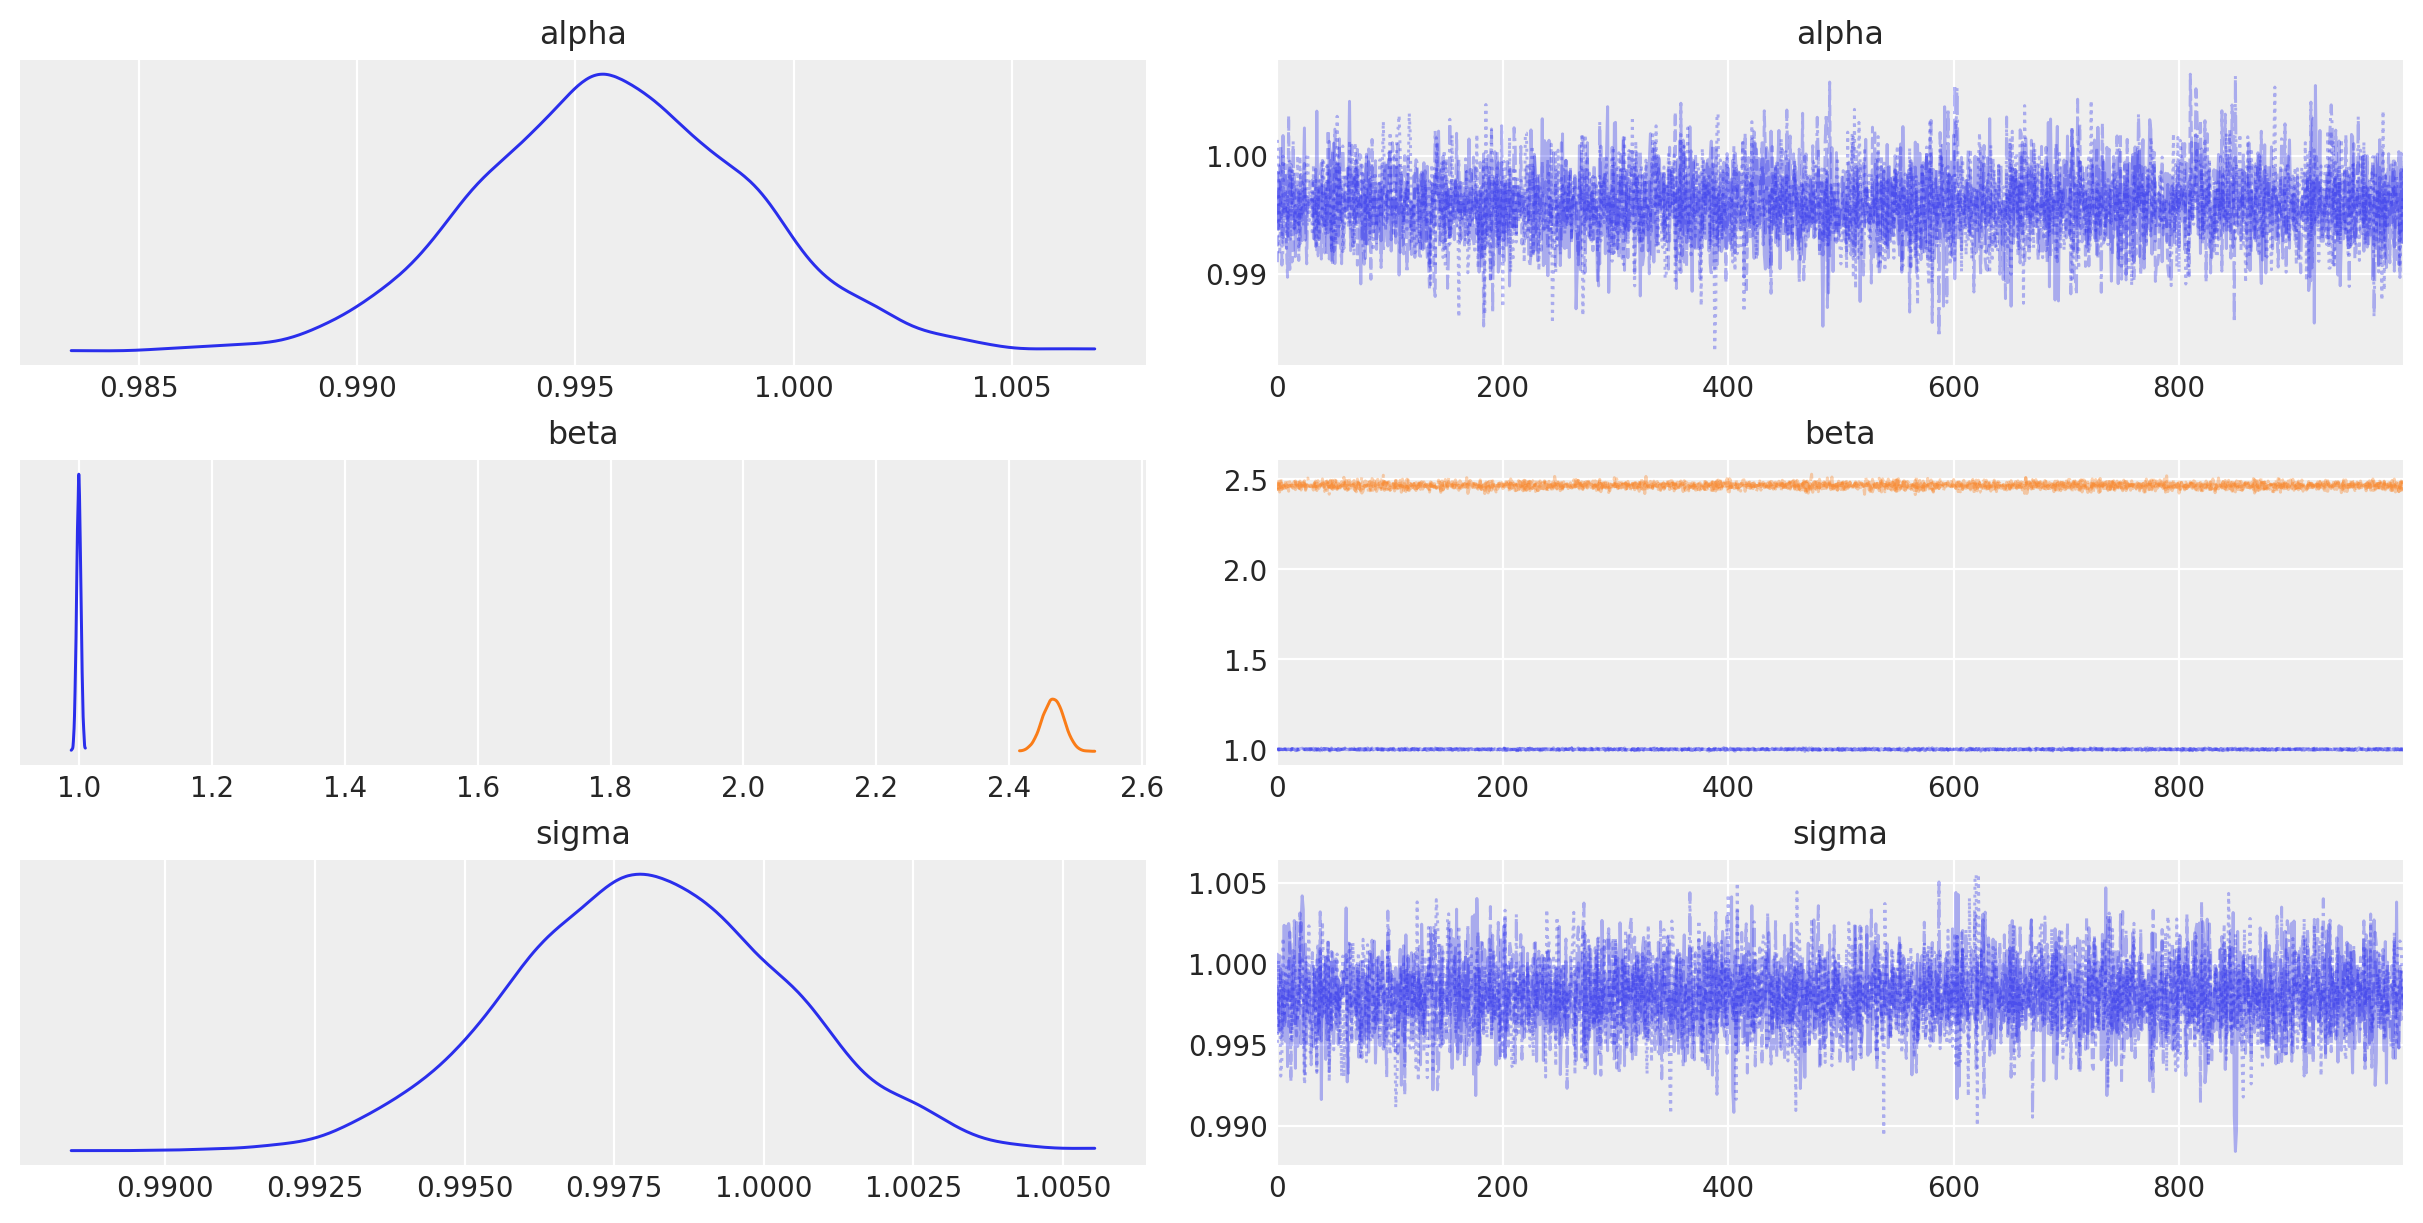

In [30]:
az.plot_trace(idata, combined=True);